In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression

 15. This problem involves the Boston data set, which we saw in the lab
 for this chapter. We will now try to predict per capita crime rate
 using the other variables in this data set. In other words, per capita
 crime rate is the response, and the other variables are the predictors.
 (a) For each predictor, fit a simple linear regression model to predict
 the response. Describe your results. In which of the models is
 there a statistically significant association between the predictor
 and the response? Create some plots to back up your assertions.

In [4]:
BostonData=pd.read_csv("D:\ML&Fintech\data_ML&Fintech\Boston.csv")
BostonData.head()
BostonData=BostonData.drop('Unnamed: 0', axis=1)

<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Acer\AppData\Local\Temp\ipykernel_444\1290040118.py:1: SyntaxWarning: invalid escape sequence '\M'
  BostonData=pd.read_csv("D:\ML&Fintech\data_ML&Fintech\Boston.csv")


In [5]:
BostonData.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [11]:
def simple_lr_builder(data, response, poly=False):
    p_values = []
    coefficients = []
    predictors = BostonData.drop([response], axis=1).columns
    for predictor in predictors:
        if not(poly):
            formula = f'{response} ~ {predictor}'
        else:
            formula = f'{response} ~ {predictor} + np.power({predictor}, 2) + np.power({predictor}, 3)'
        model = smf.ols(formula, data=data).fit()
        p_values.append({predictor: format(model.pvalues.loc[predictor], '.3f')})
        coefficients.append(model.params[1])
        if poly:
            print(model.summary())
    return p_values, coefficients

In [12]:
p_values, _ = simple_lr_builder(BostonData, 'crim')
p_values

C:\Users\Acer\AppData\Local\Temp\ipykernel_444\3386658677.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coefficients.append(model.params[1])
C:\Users\Acer\AppData\Local\Temp\ipykernel_444\3386658677.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coefficients.append(model.params[1])
C:\Users\Acer\AppData\Local\Temp\ipykernel_444\3386658677.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coefficients.append(model.par

[{'zn': '0.000'},
 {'indus': '0.000'},
 {'chas': '0.209'},
 {'nox': '0.000'},
 {'rm': '0.000'},
 {'age': '0.000'},
 {'dis': '0.000'},
 {'rad': '0.000'},
 {'tax': '0.000'},
 {'ptratio': '0.000'},
 {'lstat': '0.000'},
 {'medv': '0.000'}]

(b) Fit a multiple regression model to predict the response using
 all of the predictors. Describe your results. For which predictors
 can we reject the null hypothesis H0 : βj = 0?

In [13]:
x = BostonData.drop(['crim'], axis=1)
y = BostonData['crim']
boston_ml = sm.OLS(y, sm.add_constant(x)).fit()
boston_ml.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   crim   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                  0.436
Method:                 Least Squares   F-statistic:                     33.52
Date:                Sun, 19 Oct 2025   Prob (F-statistic):           2.03e-56
Time:                        12:41:57   Log-Likelihood:                -1655.4
No. Observations:                 506   AIC:                             3337.
Df Residuals:                     493   BIC:                             3392.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.7784      7.082      1.946      0.052      -0.136      27.693
zn             0.0457      0.019      2.433      0.015       0.009       0.083
indus         -0.0584      0.084     -0.698      0.486      -0.223       0.106
chas          -0.8254      1.183     -0.697      0.486      -3.150       1.500
nox           -9.9576      5.290     -1.882      0.060     -20.351       0.436
rm             0.6289      0.607      1.036      0.301      -0.564       1.822
age           -0.0008      0.018     -0.047      0.962      -0.036       0.034
dis           -1.0122      0.282     -3.584      0.000      -1.567      -0.457
rad            0.6125      0.088      6.997      0.000       0.440       0.784
tax           -0.0038      0.005     -0.730      0.466      -0.014       0.006
ptratio       -0.3041      0.186     -1.632      0.103      -0.670       0.062
lstat          0.1388      0.076      1.833      0.067      -0.010       0.288
medv          -0.2201      0.060     -3.678      0.000      -0.338      -0.103
==============================================================================
Omnibus:                      663.436   Durbin-Watson:                   1.516
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            80856.852
Skew:                           6.579   Prob(JB):                         0.00
Kurtosis:                      63.514   Cond. No.                     1.24e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.24e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

 (c) How do your results from (a) compare to your results from (b)?
 Create a plot displaying the univariate regression coefficients
 from (a) on the x-axis, and the multiple regression coefficients
 from (b) on the y-axis. That is, each predictor is displayed as a
 single point in the plot. Its coefficient in a simple linear regres
sion model is shown on the x-axis, and its coefficient estimate
 in the multiple linear regression model is shown on the y-axis.

C:\Users\Acer\AppData\Local\Temp\ipykernel_444\3386658677.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coefficients.append(model.params[1])
C:\Users\Acer\AppData\Local\Temp\ipykernel_444\3386658677.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coefficients.append(model.params[1])
C:\Users\Acer\AppData\Local\Temp\ipykernel_444\3386658677.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coefficients.append(model.par

Text(0, 0.5, 'Multiple Linear Reg. Coefficients')

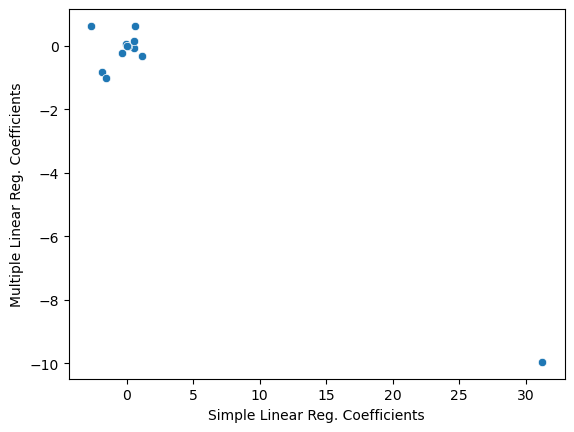

In [14]:
_, slr_coeffs = simple_lr_builder(BostonData, 'crim')
mlr_coeffs = boston_ml.params[1:]

ax = sns.scatterplot(x=slr_coeffs, y=mlr_coeffs)
ax.set_xlabel('Simple Linear Reg. Coefficients')
ax.set_ylabel('Multiple Linear Reg. Coefficients')

(d) Is there evidence of non-linear association between any of the
 predictors and the response? To answer this question, for each
 predictor X, fit a model of the form
 Y =β0+β1X+β2X2+β3X3+ϵ.

In [15]:
# fit a simple polynomial regression for each predictor to predict per capita crime
simple_lr_builder(BostonData, 'crim', poly=True)

C:\Users\Acer\AppData\Local\Temp\ipykernel_444\3386658677.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coefficients.append(model.params[1])
C:\Users\Acer\AppData\Local\Temp\ipykernel_444\3386658677.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coefficients.append(model.params[1])
C:\Users\Acer\AppData\Local\Temp\ipykernel_444\3386658677.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coefficients.append(model.par

                            OLS Regression Results                            
Dep. Variable:                   crim   R-squared:                       0.058
Model:                            OLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                     10.35
Date:                Sun, 19 Oct 2025   Prob (F-statistic):           1.28e-06
Time:                        12:44:07   Log-Likelihood:                -1791.2
No. Observations:                 506   AIC:                             3590.
Df Residuals:                     502   BIC:                             3607.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           4.8461      0.433     

C:\Users\Acer\AppData\Local\Temp\ipykernel_444\3386658677.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coefficients.append(model.params[1])
C:\Users\Acer\AppData\Local\Temp\ipykernel_444\3386658677.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coefficients.append(model.params[1])
C:\Users\Acer\AppData\Local\Temp\ipykernel_444\3386658677.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coefficients.append(model.par

([{'zn': '0.003'},
  {'indus': '0.000'},
  {'chas': '0.209'},
  {'nox': '0.000'},
  {'rm': '0.212'},
  {'age': '0.143'},
  {'dis': '0.000'},
  {'rad': '0.623'},
  {'tax': '0.110'},
  {'ptratio': '0.003'},
  {'lstat': '0.335'},
  {'medv': '0.000'}],
 [np.float64(-0.3321884147214827),
  np.float64(-1.9652129343068803),
  np.float64(-0.630925516934586),
  np.float64(-1279.3712516621827),
  np.float64(-39.15013633707046),
  np.float64(0.27365313056045115),
  np.float64(-15.554353488050914),
  np.float64(0.5127360382141881),
  np.float64(-0.1533096129911227),
  np.float64(-82.3605377209372),
  np.float64(-0.44906558716478223),
  np.float64(-5.094830543445157)])